In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


In [3]:
# Load all 6 Uber datasets
path = '/content/drive/MyDrive/uber-data/'

apr = pd.read_csv(path + 'uber-raw-data-apr14.csv')
may = pd.read_csv(path + 'uber-raw-data-may14.csv')
jun = pd.read_csv(path + 'uber-raw-data-jun14.csv')
jul = pd.read_csv(path + 'uber-raw-data-jul14.csv')
aug = pd.read_csv(path + 'uber-raw-data-aug14.csv')
sep = pd.read_csv(path + 'uber-raw-data-sep14.csv')

# Combine all into one dataframe
df = pd.concat([apr, may, jun, jul, aug, sep], ignore_index=True)

print("Total records:", len(df))
print("Shape:", df.shape)

Total records: 4534327
Shape: (4534327, 4)


In [4]:
print("First 5 rows:")
df.head()

First % rows:


,Date/Time,Lat,Lon,Base
0,4/1/2014 0:11:00,40.7690,-73.9549,B02512
1,4/1/2014 0:17:00,40.7267,-74.0345,B02512
2,4/1/2014 0:21:00,40.7316,-73.9873,B02512
3,4/1/2014 0:28:00,40.7588,-73.9776,B02512
4,4/1/2014 0:33:00,40.7594,-73.9722,B02512


In [6]:
# Basic info
print("Columns:", df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
print("\nMissing Values:")
print(df.isnull().sum())
print("\nBasic Stats:")
df.describe()

Columns: ['Date/Time', 'Lat', 'Lon', 'Base']

Data Types:
Date/Time     object
Lat          float64
Lon          float64
Base          object
dtype: object

Missing Values:
Date/Time    0
Lat          0
Lon          0
Base         0
dtype: int64

Basic Stats:


,Lat,Lon
count,4.534327e+06,4.534327e+06
mean,4.073926e+01,-7.397302e+01
std,3.994991e-02,5.726670e-02
min,3.965690e+01,-7.492900e+01
25%,4.072110e+01,-7.399650e+01
50%,4.074220e+01,-7.398340e+01
75%,4.076100e+01,-7.396530e+01
max,4.211660e+01,-7.206660e+01


In [7]:
#Data Preprocessing

# Convert Date/Time to datetime format
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Extract useful time features
df['day'] = df['Date/Time'].dt.day
df['month'] = df['Date/Time'].dt.month
df['hour'] = df['Date/Time'].dt.hour
df['weekday'] = df['Date/Time'].dt.day_name()

print("New columns added!")
print(df.head())

New columns added!
            Date/Time      Lat      Lon    Base  day  month  hour  weekday
0 2014-04-01 00:11:00  40.7690 -73.9549  B02512    1      4     0  Tuesday
1 2014-04-01 00:17:00  40.7267 -74.0345  B02512    1      4     0  Tuesday
2 2014-04-01 00:21:00  40.7316 -73.9873  B02512    1      4     0  Tuesday
3 2014-04-01 00:28:00  40.7588 -73.9776  B02512    1      4     0  Tuesday
4 2014-04-01 00:33:00  40.7594 -73.9722  B02512    1      4     0  Tuesday


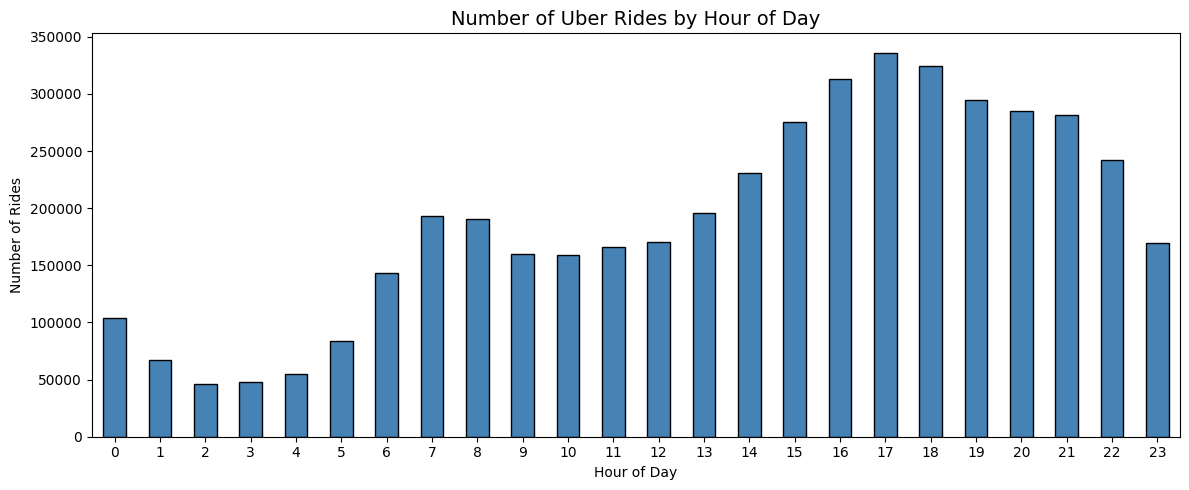

In [8]:
# EDA and Visualization
# Visualization 1

# Rides per Hour
plt.figure(figsize=(12,5))
df['hour'].value_counts().sort_index().plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Number of Uber Rides by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


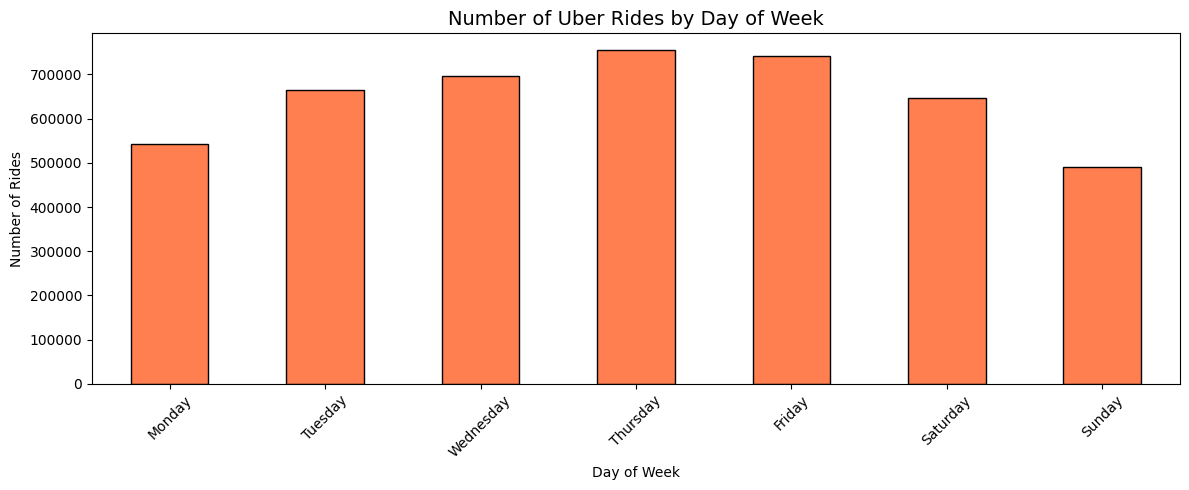

In [9]:
# Visualization 2

# Rides per Weekday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(12,5))
df['weekday'].value_counts().reindex(weekday_order).plot(kind='bar', color='coral', edgecolor='black')
plt.title('Number of Uber Rides by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Number of Rides')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

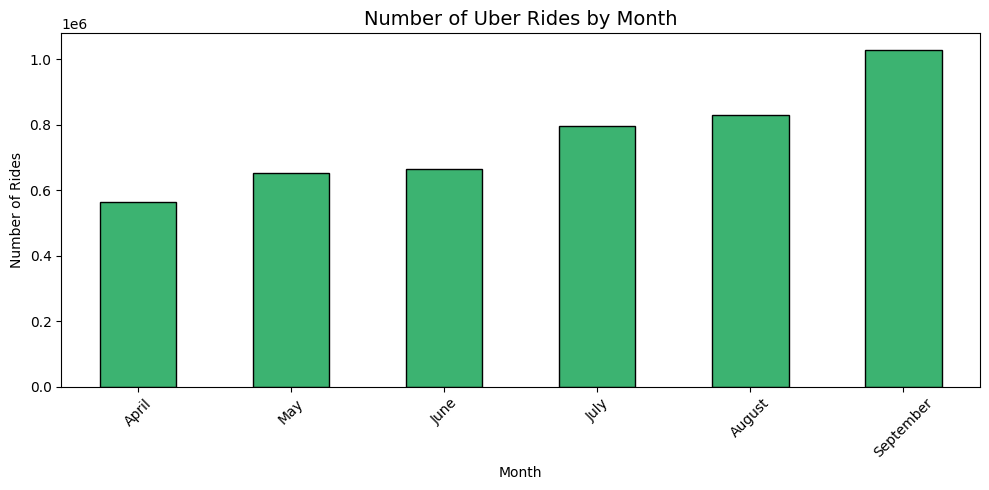

In [10]:
# Visualization 3 - Rides per month

# Rides per Month
month_names = {4:'April', 5:'May', 6:'June', 7:'July', 8:'August', 9:'September'}

plt.figure(figsize=(10,5))
df['month'].value_counts().sort_index().plot(kind='bar', color='mediumseagreen', edgecolor='black')
plt.title('Number of Uber Rides by Month', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.xticks(ticks=range(6), labels=month_names.values(), rotation=45)
plt.tight_layout()
plt.show()

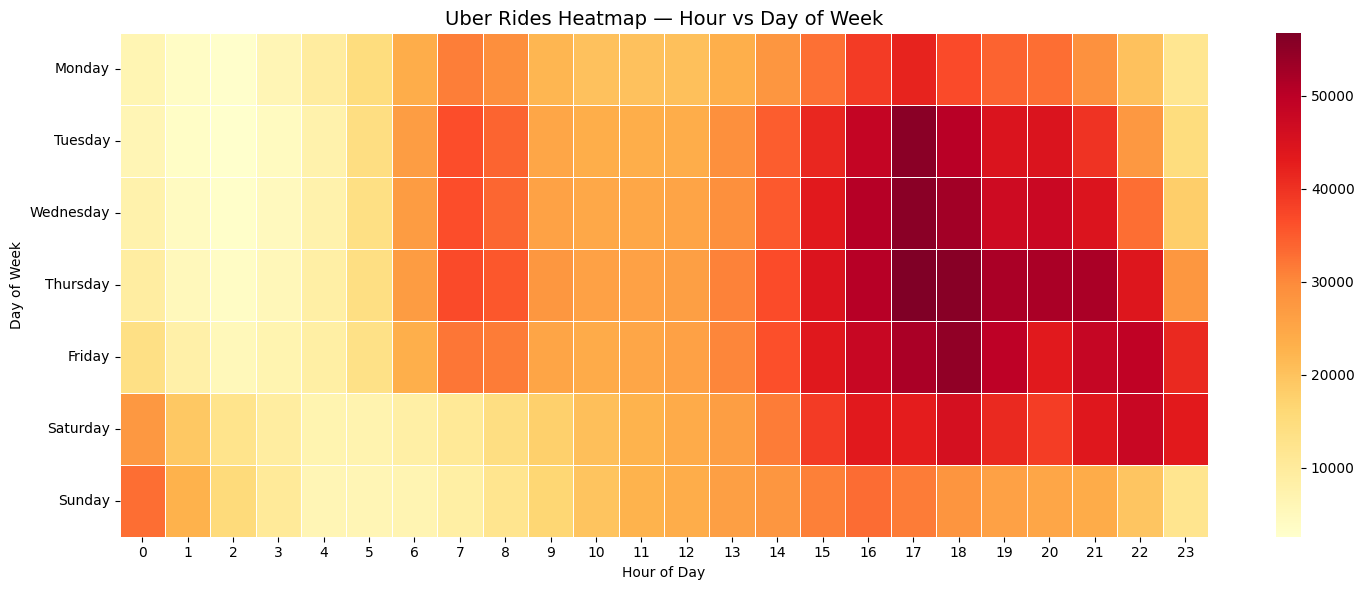

In [11]:
# Visualization 4 - Heatmap of Rides by Hour and Weekday

# Heatmap - Hour vs Weekday
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

pivot = df.groupby(['weekday', 'hour']).size().unstack()
pivot = pivot.reindex(weekday_order)

plt.figure(figsize=(15,6))
sns.heatmap(pivot, cmap='YlOrRd', linewidths=0.5)
plt.title('Uber Rides Heatmap — Hour vs Day of Week', fontsize=14)
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.tight_layout()
plt.show()

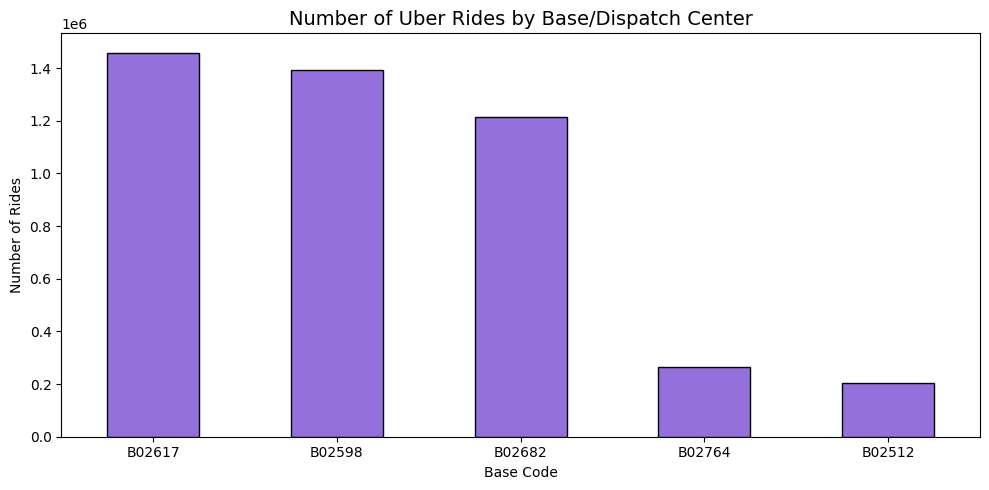

In [12]:
# Visualization % - Rides Per Base

# Rides per Base
plt.figure(figsize=(10,5))
df['Base'].value_counts().plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Number of Uber Rides by Base/Dispatch Center', fontsize=14)
plt.xlabel('Base Code')
plt.ylabel('Number of Rides')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

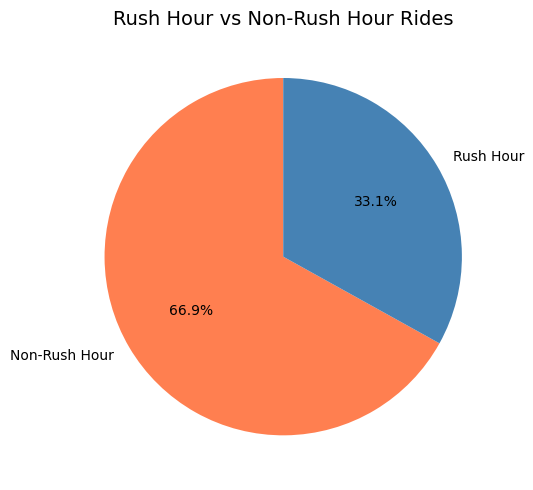

In [13]:
# Visualization 6 - Rush Hour vs Non-Rush Hour

# Rush Hour Analysis
df['rush_hour'] = df['hour'].apply(lambda x: 'Rush Hour' if x in [7,8,9,17,18,19] else 'Non-Rush Hour')

plt.figure(figsize=(8,5))
df['rush_hour'].value_counts().plot(kind='pie', autopct='%1.1f%%',
colors=['coral', 'steelblue'], startangle=90)
plt.title('Rush Hour vs Non-Rush Hour Rides', fontsize=14)
plt.ylabel('')
plt.tight_layout()
plt.show()

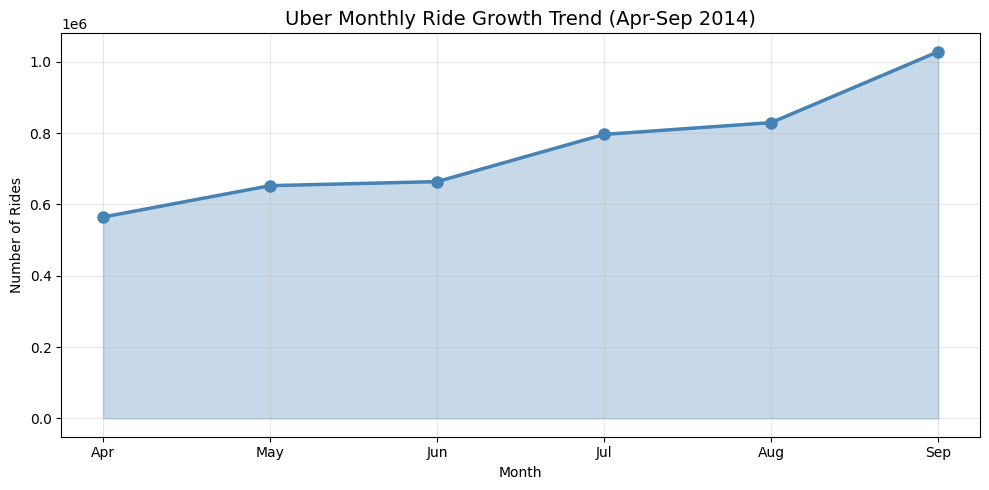

In [14]:
# Visualization 7 - Monthly Growth Trend

# Monthly Growth Trend
monthly_rides = df.groupby('month').size().reset_index(name='rides')
month_names = {4:'Apr', 5:'May', 6:'Jun', 7:'Jul', 8:'Aug', 9:'Sep'}
monthly_rides['month_name'] = monthly_rides['month'].map(month_names)

plt.figure(figsize=(10,5))
plt.plot(monthly_rides['month_name'], monthly_rides['rides'],
         marker='o', color='steelblue', linewidth=2.5, markersize=8)
plt.fill_between(monthly_rides['month_name'], monthly_rides['rides'], alpha=0.3, color='steelblue')
plt.title('Uber Monthly Ride Growth Trend (Apr-Sep 2014)', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Number of Rides')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

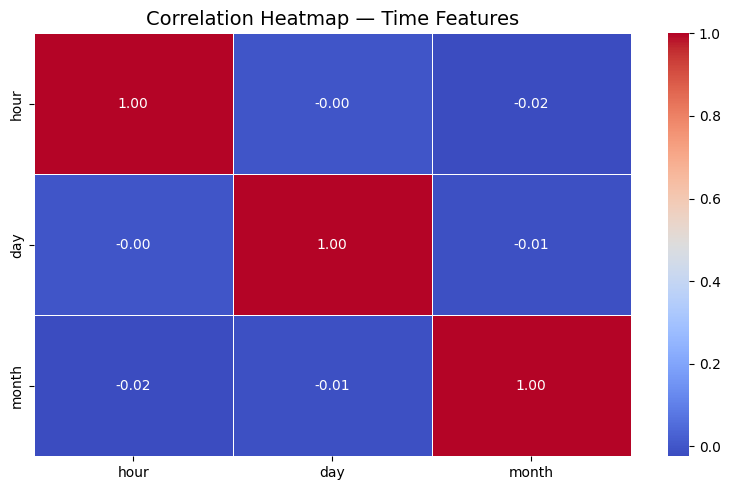

In [15]:
# Final Visualization - Correlation Heatmap

# Correlation Heatmap
plt.figure(figsize=(8,5))
corr = df[['hour', 'day', 'month']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap — Time Features', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# ML Demand Forecasting Model

In [16]:
# Prepare data for ML model
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# Create hourly demand dataframe
df_ml = df.groupby(['month', 'day', 'hour', 'weekday']).size().reset_index(name='ride_count')

# Encode weekday to number
weekday_map = {'Monday':0, 'Tuesday':1, 'Wednesday':2, 'Thursday':3,
               'Friday':4, 'Saturday':5, 'Sunday':6}
df_ml['weekday_num'] = df_ml['weekday'].map(weekday_map)

print("ML Dataset Shape:", df_ml.shape)
print(df_ml.head())

ML Dataset Shape: (4391, 6)
   month  day  hour  weekday  ride_count  weekday_num
0      4    1     0  Tuesday         138            1
1      4    1     1  Tuesday          66            1
2      4    1     2  Tuesday          53            1
3      4    1     3  Tuesday          93            1
4      4    1     4  Tuesday         166            1


In [17]:
# Define features and target
X = df_ml[['month', 'day', 'hour', 'weekday_num']]
y = df_ml['ride_count']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

# Train Random Forest Model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

print("\nModel trained successfully!")

Training samples: 3512
Testing samples: 879

Model trained successfully!


In [18]:
# Evaluate Model
y_pred = model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results:")
print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"R² Score: {r2:.4f}")
print(f"Model Accuracy: {r2*100:.2f}%")

Model Evaluation Results:
Mean Absolute Error (MAE): 96.59
R² Score: 0.9423
Model Accuracy: 94.23%


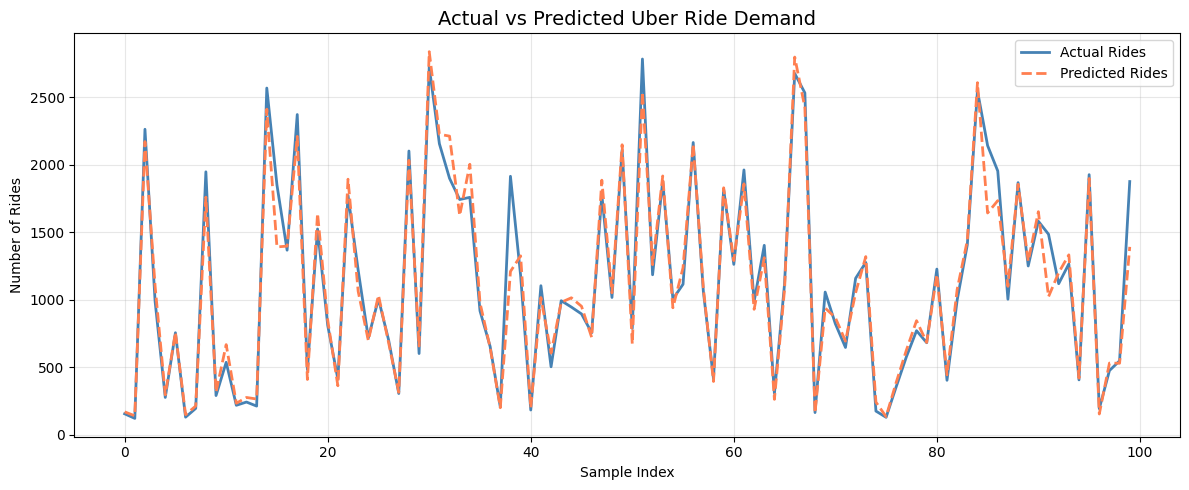

In [19]:
# Actual vs Predicted Plot
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:100], label='Actual Rides', color='steelblue', linewidth=2)
plt.plot(y_pred[:100], label='Predicted Rides', color='coral', linewidth=2, linestyle='--')
plt.title('Actual vs Predicted Uber Ride Demand', fontsize=14)
plt.xlabel('Sample Index')
plt.ylabel('Number of Rides')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

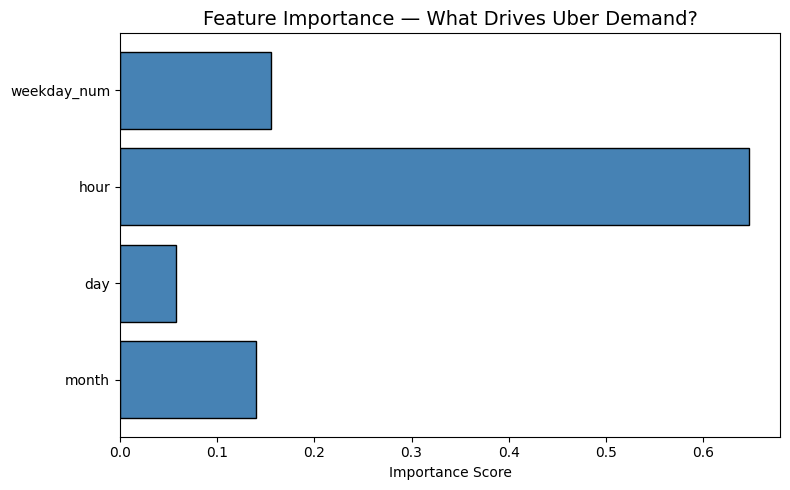

In [20]:
# Feature Importance
features = ['month', 'day', 'hour', 'weekday_num']
importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features, importance, color='steelblue', edgecolor='black')
plt.title('Feature Importance — What Drives Uber Demand?', fontsize=14)
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

In [21]:
# Save clean data for Power BI
df_export = df[['Date/Time', 'Lat', 'Lon', 'Base', 'hour', 'day', 'month', 'weekday', 'rush_hour']]
df_export.to_csv('/content/drive/MyDrive/uber-data/uber_clean_data.csv', index=False)

# Save hourly demand for Power BI
df_ml.to_csv('/content/drive/MyDrive/uber-data/uber_hourly_demand.csv', index=False)

print("Files saved successfully!")

Files saved successfully!
